In [24]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 4.8 MB/s eta 0:00:09
   - -------------------------------------- 1.3/40.2 MB 3.7 MB/s eta 0:00:11
   -- ------------------------------------- 2.1/40.2 MB 3.7 MB/s eta 0:00:11
   --- ------------------------------------ 3.4/40.2 MB 4.2 MB/s eta 0:00:09
   --- ------------------------------------ 3.9/40.2 MB 4.3 MB/s eta 0:00:09
   ---- ----------------------------------- 4.7/40.2 MB 4.3 MB/s eta 0:00:09
   ----- ---------------------------------- 6.0/40.2 MB 4.1 MB/s eta 0:00:09
   ------- -------------------------------- 7.1/40.2 MB 4.2 MB/s eta 0:00:08
   ------- -------------------------------- 7.9/40.2 MB 4.3 MB/s eta 0:00:08
   --------- ------------------------------ 9.7/40.2 MB 4.6 MB/s eta 0:00:07
   ---------- ----------------------------- 10.7/40.2 MB 4.7 MB/s eta 0:00:07
   ----------- ---------------------------- 12.1/40.2 MB 4.8 MB/s eta 0:00:06
   -

In [25]:
import cv2

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [14]:
dataset_path = r"Documents/brain_tumor_dataset"

In [15]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [16]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 203 images belonging to 3 classes.


In [17]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 50 images belonging to 3 classes.


In [18]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 776ms/step - accuracy: 0.3695 - loss: -52.2336 - val_accuracy: 0.3800 - val_loss: -342.6109
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 581ms/step - accuracy: 0.3892 - loss: -1323.1263 - val_accuracy: 0.3800 - val_loss: -4653.8120
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 555ms/step - accuracy: 0.3892 - loss: -9504.4600 - val_accuracy: 0.3800 - val_loss: -29451.8203
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 557ms/step - accuracy: 0.3892 - loss: -49549.5078 - val_accuracy: 0.3800 - val_loss: -126542.2422
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 596ms/step - accuracy: 0.3892 - loss: -196478.6250 - val_accuracy: 0.3800 - val_loss: -432674.1250
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 536ms/step - accuracy: 0.3892 - loss: -538862.5625 - val_accuracy: 0.3800 - val_loss: -1239062.5000
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 530ms/step - accuracy: 0.3892 - loss: -1613389.8750 - val_accuracy: 0.3800 - val_loss: -3109400.2500
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 536ms/

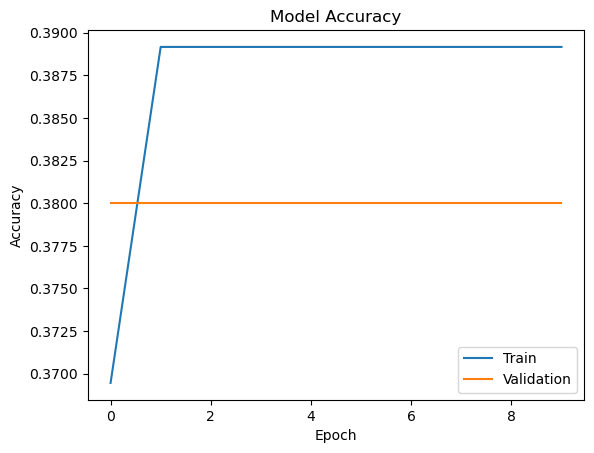

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])
plt.show()

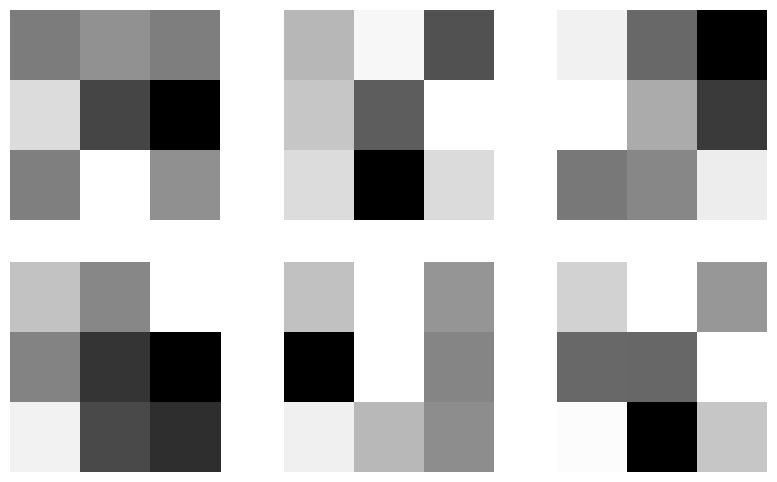

In [22]:
filters, biases = model.layers[0].get_weights()

plt.figure(figsize=(10,6))

for i in range(6):
    
    f = filters[:,:,:,i]
    
    plt.subplot(2,3,i+1)
    
    plt.imshow(f[:,:,0], cmap='gray')
    
    plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

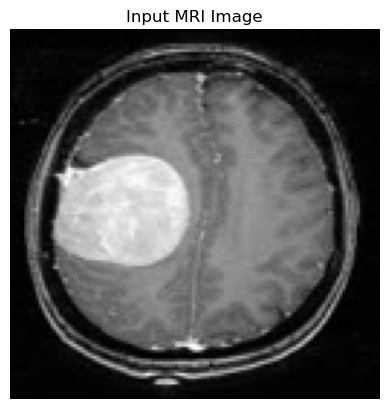

In [26]:
img_path = r"Documents/brain_tumor_dataset/yes/Y1.jpg"

img = cv2.imread(img_path)

img = cv2.resize(img,(128,128))

img = img/255.0

plt.imshow(img)
plt.title("Input MRI Image")
plt.axis("off")

In [27]:
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0] > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Tumor Detected


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

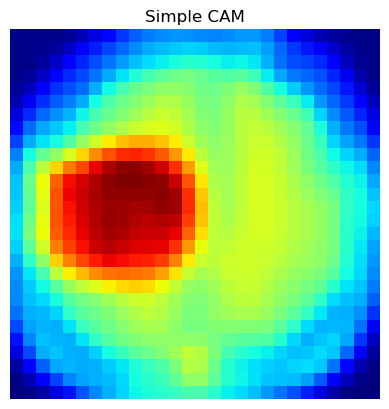

In [46]:
# get feature maps from last conv layer
feature_maps = model.layers[4].output

# create a temporary model
cam_model = tf.keras.models.Model(inputs=model.inputs, outputs=feature_maps)

# get feature maps for image
feature_maps = cam_model.predict(img)

# remove batch dimension
feature_maps = feature_maps[0]

# create heatmap by averaging filters
heatmap = np.mean(feature_maps, axis=-1)

# normalize heatmap
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# show heatmap
plt.imshow(heatmap, cmap="jet")
plt.title("Simple CAM")
plt.axis("off")